最初选取股票数据为贵州茅台  
之后做相关性检验我们选择了山西汾酒，因为所属类别和交易板块相同，便于比较  
我们的数据来源于tushare网站，时间跨度为日均数据：2022-01-01至2024-12-31的日频数据

导包

In [2]:
import tushare as ts
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.weightstats import DescrStatsW
from statsmodels.tsa.stattools import adfuller
from scipy.stats import mannwhitneyu
import streamlit as st

获取数据，可视化收益率

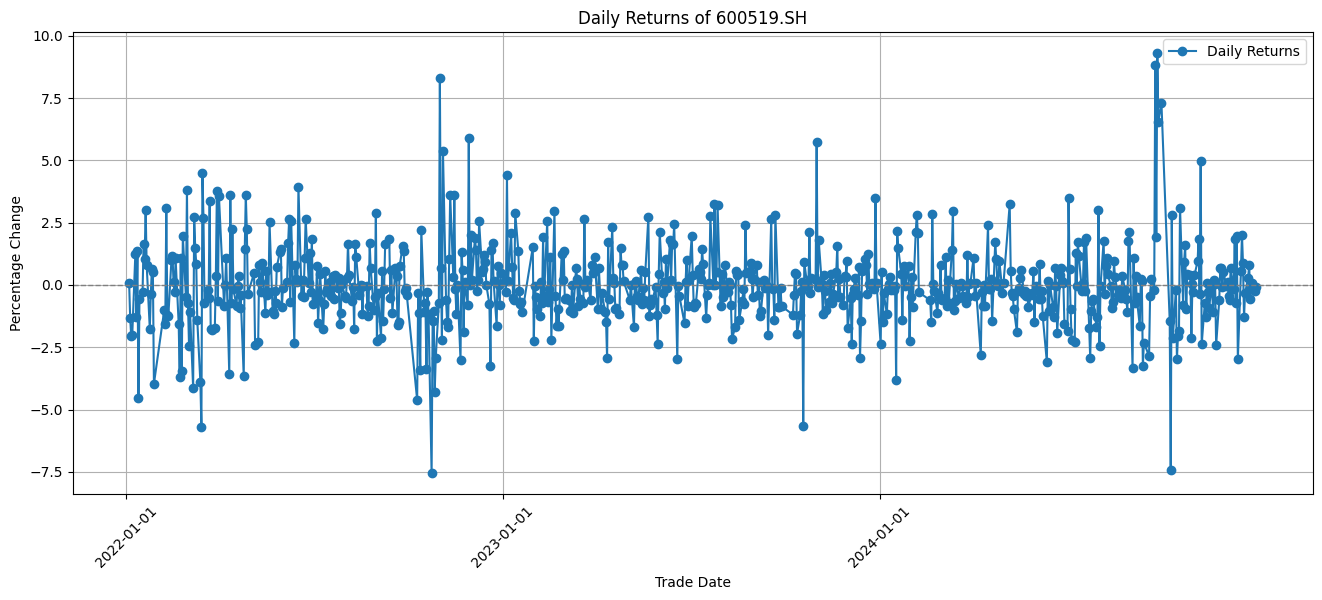

In [6]:
ts.set_token('9a4a4c825946a62743c8fb826b76a5df6f7827700c2e2c52ec165118')
pro = ts.pro_api()
pro = ts.pro_api()
df = pro.daily(ts_code='600519.SH', start_date='20220101', end_date='20241231')
df = df.iloc[:,[0,1,8]]
pct_change = df.iloc[:,2]
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df = df.sort_values('trade_date')
selected_dates = pd.to_datetime(["2022-01-01", "2023-01-01", "2024-01-01"])

plt.figure(figsize=(16, 6))
plt.plot(df['trade_date'], df['pct_chg'], marker='o', linestyle='-', label='Daily Returns')
plt.xticks(selected_dates, rotation=45)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Trade Date')
plt.ylabel('Percentage Change')
plt.title('Daily Returns of 600519.SH')
plt.legend()
plt.grid(True)

plt.show()

优秀比例和置信区间计算

In [7]:
import statsmodels.stats.proportion as smp

threshold = 1.0
success_count = (df["pct_chg"] > threshold).sum()
total_count = df["pct_chg"].count()
success_ratio = success_count / total_count

conf_int_low, conf_int_high = smp.proportion_confint(success_count, total_count, alpha=0.05, method='normal')
print("优秀收益比例:", success_ratio)
print("95% 置信区间: ({:.4f}, {:.4f})".format(conf_int_low, conf_int_high))


优秀收益比例: 0.19146005509641872
95% 置信区间: (0.1628, 0.2201)


波动性计算

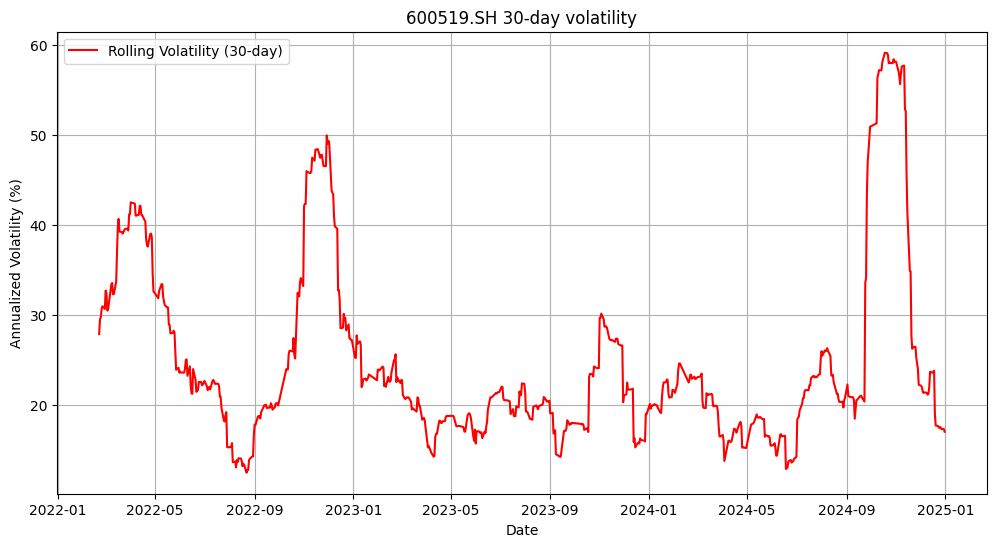

In [8]:
df["rolling_volatility"] = df["pct_chg"].rolling(window=30).std() * np.sqrt(252)


plt.figure(figsize=(12, 6))
plt.plot(df["trade_date"], df["rolling_volatility"], label="Rolling Volatility (30-day)", color='red')
plt.xlabel("Date")
plt.ylabel("Annualized Volatility (%)")
plt.title("600519.SH 30-day volatility")
plt.legend()
plt.grid()

plt.show()


中位数检验

In [9]:
from scipy.stats import median_test
df["trade_date"] = pd.to_datetime(df["trade_date"], format="%Y%m%d")
df_2022 = df[df["trade_date"].dt.year == 2022]["pct_chg"]
df_2023 = df[df["trade_date"].dt.year == 2023]["pct_chg"]
median_2022 = df_2022.median()
stat, p_value, _, _ = median_test(df_2022, df_2023)
median_2022, p_value

(-0.13324999999999998, 0.6494362837267547)

In [10]:
df

,ts_code,trade_date,pct_chg,rolling_volatility
725,600519.SH,2022-01-04,0.0600,NaN
724,600519.SH,2022-01-05,-1.3275,NaN
723,600519.SH,2022-01-06,-2.0642,NaN
722,600519.SH,2022-01-07,-2.0290,NaN
721,600519.SH,2022-01-10,1.2358,NaN
...,...,...,...,...
4,600519.SH,2024-12-25,-0.5732,17.492421
3,600519.SH,2024-12-26,-0.1444,17.478908
2,600519.SH,2024-12-27,0.0772,17.271639
1,600519.SH,2024-12-30,-0.2597,17.287070


四分位数计算

In [12]:
import numpy as np
import statsmodels.stats.api as sms
q1 = df["pct_chg"].quantile(0.25)
q3 = df["pct_chg"].quantile(0.75)

iqr = q3 - q1

n = len(df["pct_chg"])
se_q = (1.57 * iqr) / np.sqrt(n)

ci_q1 = (q1 - 1.96 * se_q, q1 + 1.96 * se_q)
ci_q3 = (q3 - 1.96 * se_q, q3 + 1.96 * se_q)

print(f"Q1: {q1}, 95% CI: {ci_q1}")
print(f"Q3: {q3}, 95% CI: {ci_q3}")


Q1: -0.79165, 95% CI: (-0.9571710364132475, -0.6261289635867524)
Q3: 0.657675, 95% CI: (0.49215396358675245, 0.8231960364132476)


相关性检验

In [37]:
df_2 = pro.daily(ts_code='600809.SH', start_date='20220101', end_date='20241231')
df_2 = df_2.iloc[:,[0,1,8]]
pct_change_2 = df.iloc[:,2]
returns_mt = df["pct_chg"].dropna()
returns_fj = df_2["pct_chg"].dropna()

min_length = min(len(returns_mt), len(returns_fj))
returns_mt = returns_mt[:min_length]
returns_fj = returns_fj[:min_length]
pearson_corr, pearson_p_value = stats.pearsonr(returns_mt, returns_fj)
spearman_corr, spearman_p_value = stats.spearmanr(returns_mt, returns_fj)
kendall_corr, kendall_p_value = stats.kendalltau(returns_mt, returns_fj)

correlation_results = {
    "Pearson Correlation": (pearson_corr, pearson_p_value),
    "Spearman Correlation": (spearman_corr, spearman_p_value),
    "Kendall Correlation": (kendall_corr, kendall_p_value),
}

correlation_results


{'Pearson Correlation': (0.11847308246466251, 0.0013840676081251385),
 'Spearman Correlation': (0.07052707552018768, 0.0575119039342837),
 'Kendall Correlation': (0.04769622157997114, 0.0544784129946796)}

趋势性检验

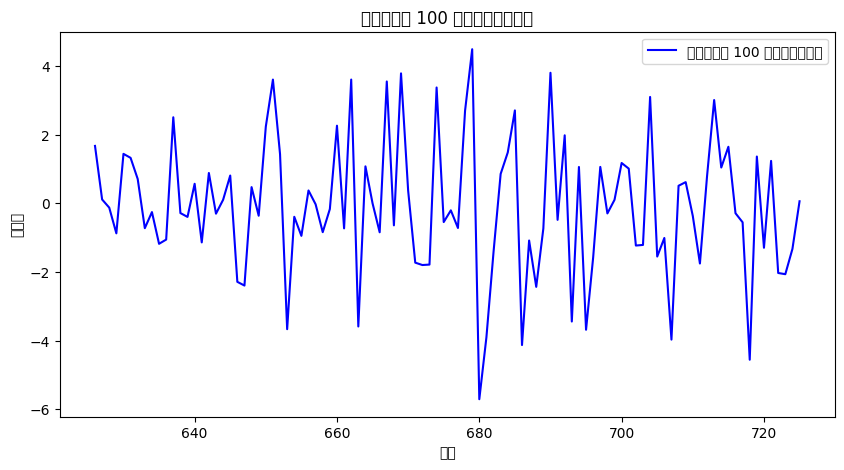


===== Cox-Stuart 趋势性检验结果 =====
正号数量（上升趋势次数）: 29
负号数量（下降趋势次数）: 21
二项检验 p 值: 0.3222363203575469
❌ 收益率序列无显著趋势（p >= 0.05）

===== 滚动窗口 Cox-Stuart 趋势性检验 =====
正号数量（上升趋势次数）: 7
负号数量（下降趋势次数）: 8
二项检验 p 值: 1.0000000000000002
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 7
负号数量（下降趋势次数）: 8
二项检验 p 值: 1.0000000000000002
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 7
负号数量（下降趋势次数）: 8
二项检验 p 值: 1.0000000000000002
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 6
负号数量（下降趋势次数）: 9
二项检验 p 值: 0.6072387695312499
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 7
负号数量（下降趋势次数）: 8
二项检验 p 值: 1.0000000000000002
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 8
负号数量（下降趋势次数）: 7
二项检验 p 值: 1.0000000000000002
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 9
负号数量（下降趋势次数）: 6
二项检验 p 值: 0.6072387695312499
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 8
负号数量（下降趋势次数）: 7
二项检验 p 值: 1.0000000000000002
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 7
负号数量（下降趋势次数）: 8
二项检验 p 值: 1.0000000000000002
❌ 收益率序列无显著趋势（p >= 0.05）
正号数量（上升趋势次数）: 8
负号数量（下降趋势次数）: 7
二项检验 p 值: 1.0000000000000002
❌ 收益率序列无显著趋势（p >= 0.

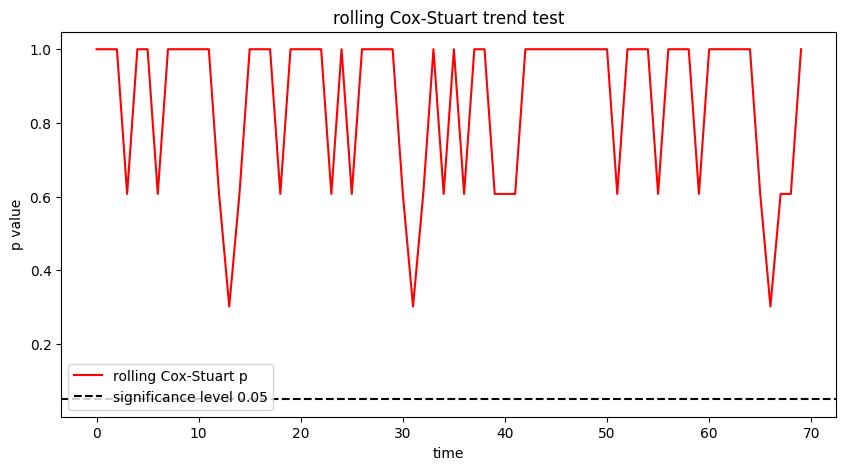

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

def cox_stuart_trend_test(returns):
    """
    Cox-Stuart 趋势性检验，判断收益率序列是否具有趋势。
    :param returns: 股票收益率序列 (Pandas Series 或 Numpy 数组)
    :return: p 值
    """
    returns = np.array(returns)  
    if np.all(returns == returns[0]):
        print("⚠️ 所有收益率数据点相等，无法进行趋势检验！请检查数据。")
        return None

    n = len(returns)
    if n % 2 == 1:
        n -= 1  

    first_half = returns[:n//2]
    second_half = returns[n//2:n]

    diff = second_half - first_half
    signs = np.sign(diff) 

    if np.all(signs == 0):
        print("⚠️ 数据变化极小，导致所有配对数据相等，趋势无法判断。尝试扩大数据或加小噪声！")
        return None

    pos_count = np.sum(signs > 0)
    neg_count = np.sum(signs < 0)

    p_value = 2 * stats.binom.cdf(min(pos_count, neg_count), pos_count + neg_count, 0.5)

    print(f"正号数量（上升趋势次数）: {pos_count}")
    print(f"负号数量（下降趋势次数）: {neg_count}")
    print(f"二项检验 p 值: {p_value}")

    if p_value < 0.05:
        print("✅ 收益率序列具有显著趋势（p < 0.05）")
    else:
        print("❌ 收益率序列无显著趋势（p >= 0.05）")

    return p_value

def rolling_cox_stuart_test(returns, window=30):
    """
    使用滚动窗口版本的 Cox-Stuart 趋势检验
    :param returns: 股票收益率序列
    :param window: 窗口大小（如 30 表示用最近 30 天数据进行趋势检测）
    :return: p 值序列
    """
    p_values = []
    for i in range(len(returns) - window):
        subset = returns[i : i + window]
        p_val = cox_stuart_trend_test(subset)
        p_values.append(p_val if p_val is not None else 1.0)  
    return np.array(p_values)

# ========== 1. 选取前 100 个交易日收益率数据 ==========
returns_mt_100 = returns_mt[:100]

# **数据可视化**
plt.figure(figsize=(10, 5))
plt.plot(returns_mt_100, label="贵州茅台前 100 个交易日收益率", color="blue")
plt.xlabel("时间")
plt.ylabel("收益率")
plt.title("贵州茅台前 100 交易日收益率趋势")
plt.legend()
plt.show()

# ========== 2. 运行 Cox-Stuart 趋势性检验 ==========
print("\n===== Cox-Stuart 趋势性检验结果 =====")
p_value_cs = cox_stuart_trend_test(returns_mt_100)

# ========== 3. 运行滚动窗口 Cox-Stuart 检验 ==========
print("\n===== 滚动窗口 Cox-Stuart 趋势性检验 =====")
p_values_rolling = rolling_cox_stuart_test(returns_mt_100, window=30)

# **可视化滚动窗口 p 值变化趋势**
plt.figure(figsize=(10, 5))
plt.plot(p_values_rolling, label="rolling Cox-Stuart p", color="red")
plt.axhline(0.05, linestyle="--", color="black", label="significance level 0.05")
plt.xlabel("time")
plt.ylabel("p value")
plt.title("rolling Cox-Stuart trend test")
plt.legend()
plt.show()


辛普森悖论检验

In [46]:
import numpy as np
import pandas as pd

assert len(returns_mt) == len(returns_fj), "两列收益率数据长度必须相同！"
df = pd.DataFrame({
    "moutai_pct": returns_mt,
    "fenjiu_pct": returns_fj
})

df["market_condition"] = np.where(df["moutai_pct"] > 0, "Bull", "Bear")
OR_list = []
for condition in df["market_condition"].unique():
    subset = df[df["market_condition"] == condition]

    A_k = (subset["moutai_pct"] > 0).sum()  
    B_k = (subset["moutai_pct"] <= 0).sum() 
    C_k = (subset["fenjiu_pct"] > 0).sum()  
    D_k = (subset["fenjiu_pct"] <= 0).sum() 

    A_k += 0.5
    B_k += 0.5
    C_k += 0.5
    D_k += 0.5

    OR_k = (A_k * D_k) / (B_k * C_k)
    OR_list.append(OR_k)

    print(f"\n市场状态: {condition}")
    print(f"A_k (茅台收益为正): {A_k}, B_k (茅台收益为负): {B_k}")
    print(f"C_k (汾酒收益为正): {C_k}, D_k (汾酒收益为负): {D_k}")
    print(f"当前层比值比 OR_k: {OR_k}")

OR_MH = np.nanmean(OR_list)  

print("\nMantel-Haenszel 合并比值比 OR_MH:", OR_MH)

if OR_MH > 1:
    print("在不同市场状态下，茅台收益率相对于汾酒收益率更有优势。")
elif OR_MH < 1:
    print("在不同市场状态下，汾酒收益率相对于茅台更有优势，可能存在辛普森悖论。")
else:
    print("在不同市场状态下，茅台和汾酒收益率无明显差异。")



市场状态: Bear
A_k (茅台收益为正): 0.5, B_k (茅台收益为负): 400.5
C_k (汾酒收益为正): 85.5, D_k (汾酒收益为负): 315.5
当前层比值比 OR_k: 0.0046068145811887186

市场状态: Bull
A_k (茅台收益为正): 326.5, B_k (茅台收益为负): 0.5
C_k (汾酒收益为正): 242.5, D_k (汾酒收益为负): 84.5
当前层比值比 OR_k: 227.540206185567

Mantel-Haenszel 合并比值比 OR_MH: 113.7724065000741
在不同市场状态下，茅台收益率相对于汾酒收益率更有优势。
